# Lab 04: Image Transformations and Warping
### All 10 Graded Tasks

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Project root = CV_Labs folder (set Jupyter cwd to CV_Labs, or open this notebook from there)
IMAGE_PATH = Path("CVLab01") / "assets" / "image.jpg"
image = cv2.imread(str(IMAGE_PATH))
if image is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w = image.shape[:2]
print(f"Image loaded: {w}x{h} pixels")

Image loaded: 225x225 pixels


---
## Task 1: Translation and Rotation
**Scenario:** Shift and rotate a scanned document image to align it properly.

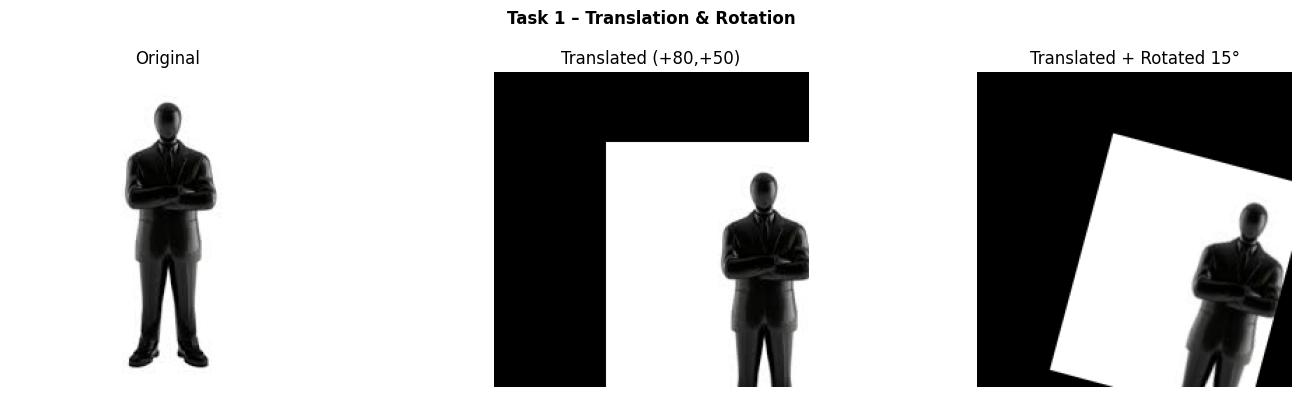

In [2]:
tx, ty = 80, 50
T = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]], dtype=np.float32)
translated = cv2.warpPerspective(image, T, (w, h))

angle = np.radians(15)
cx, cy = w // 2, h // 2
ca, sa = np.cos(angle), np.sin(angle)
R = np.array([[ca, -sa, cx*(1-ca)+cy*sa],
              [sa,  ca, cy*(1-ca)-cx*sa],
              [0,   0,  1]], dtype=np.float32)
rotated   = cv2.warpPerspective(image, R, (w, h))
combined  = cv2.warpPerspective(translated, R, (w, h))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, img, t in zip(axes, [image, translated, combined],
                      ["Original", "Translated (+80,+50)", "Translated + Rotated 15°"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis("off")
plt.suptitle("Task 1 – Translation & Rotation", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Task 2: Resize While Maintaining Aspect Ratio
**Scenario:** Resize image to fit within a 500×500 px frame without distortion.

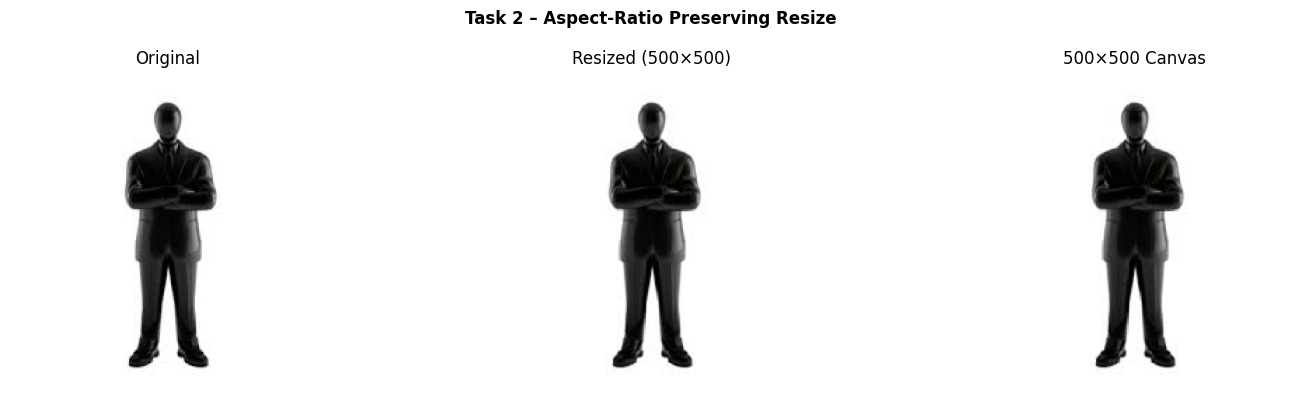

In [3]:
MAX = 500
scale = min(MAX / w, MAX / h)
new_w, new_h = int(w * scale), int(h * scale)
resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

canvas = np.zeros((MAX, MAX, 3), dtype=np.uint8)
x_off, y_off = (MAX - new_w) // 2, (MAX - new_h) // 2
canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, img, t in zip(axes, [image, resized, canvas],
                      ["Original", f"Resized ({new_w}×{new_h})", "500×500 Canvas"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis("off")
plt.suptitle("Task 2 – Aspect-Ratio Preserving Resize", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Task 3: Horizontal and Vertical Flipping
**Scenario:** Mirror an image for reflection effects in a photo editing tool.

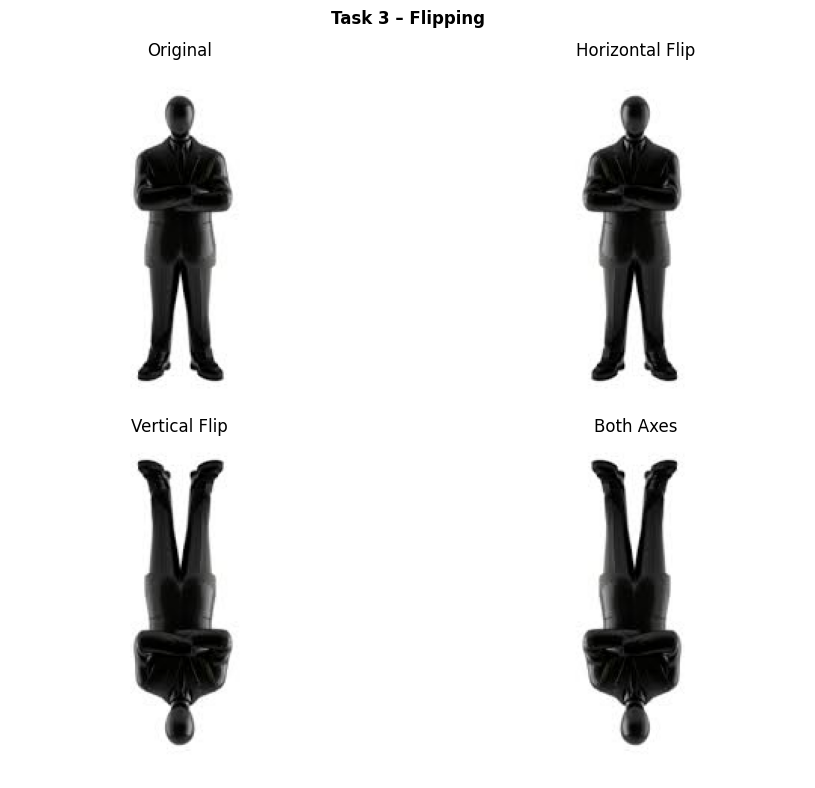

In [4]:
h_flip = cv2.flip(image, 1)
v_flip = cv2.flip(image, 0)
both   = cv2.flip(image, -1)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, img, t in zip(axes.ravel(), [image, h_flip, v_flip, both],
                      ["Original", "Horizontal Flip", "Vertical Flip", "Both Axes"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis("off")
plt.suptitle("Task 3 – Flipping", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Task 4: Perspective Transformation for Augmented Reality
**Scenario:** Transform an advertisement board to show a custom ad.

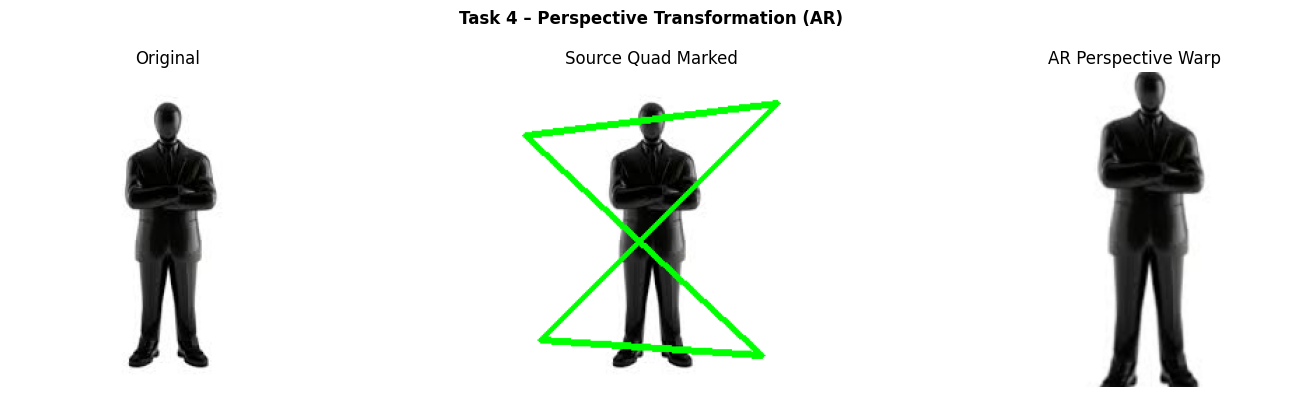

In [5]:
src_pts = np.float32([[w*0.10,h*0.20],[w*0.90,h*0.10],[w*0.15,h*0.85],[w*0.85,h*0.90]])
dst_pts = np.float32([[w*0.05,h*0.05],[w*0.95,h*0.05],[w*0.05,h*0.95],[w*0.95,h*0.95]])

M = cv2.getPerspectiveTransform(src_pts, dst_pts)
warped = cv2.warpPerspective(image, M, (w, h))

vis = image.copy()
cv2.polylines(vis, [src_pts.astype(np.int32)], True, (0,255,0), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, img, t in zip(axes, [image, vis, warped],
                      ["Original", "Source Quad Marked", "AR Perspective Warp"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis("off")
plt.suptitle("Task 4 – Perspective Transformation (AR)", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Task 5: Warp Transformation for Face Alignment
**Scenario:** Align a face in an image for a facial recognition system.

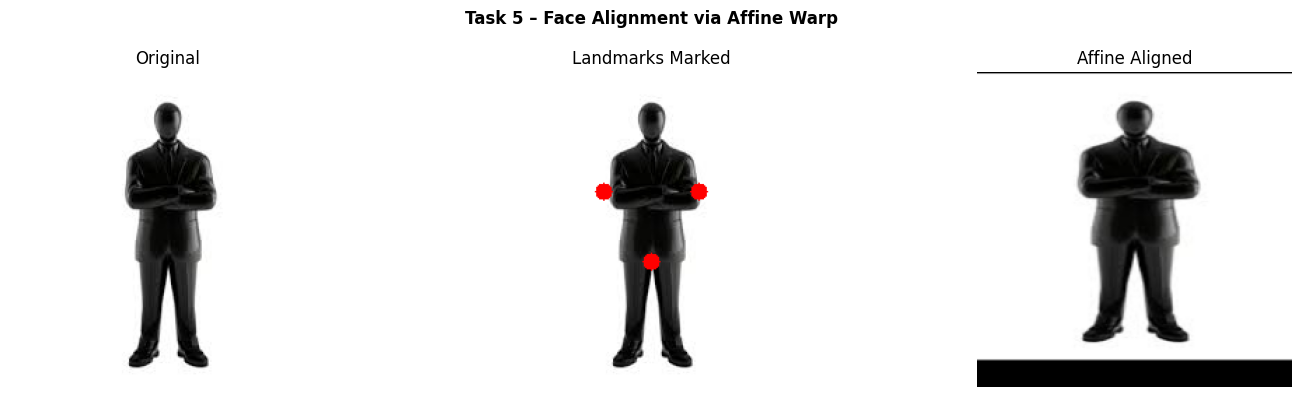

In [6]:
src_lm = np.float32([[w*0.35,h*0.38],[w*0.65,h*0.38],[w*0.50,h*0.60]])
dst_lm = np.float32([[w*0.30,h*0.35],[w*0.70,h*0.35],[w*0.50,h*0.55]])

M = cv2.getAffineTransform(src_lm, dst_lm)
aligned = cv2.warpAffine(image, M, (w, h))

vis = image.copy()
for pt in src_lm.astype(np.int32):
    cv2.circle(vis, tuple(pt), max(6,w//80), (0,0,255), -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, img, t in zip(axes, [image, vis, aligned],
                      ["Original", "Landmarks Marked", "Affine Aligned"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis("off")
plt.suptitle("Task 5 – Face Alignment via Affine Warp", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Task 6: Shearing to Simulate a 3D Effect
**Scenario:** Create a slanted text effect for an artistic poster.

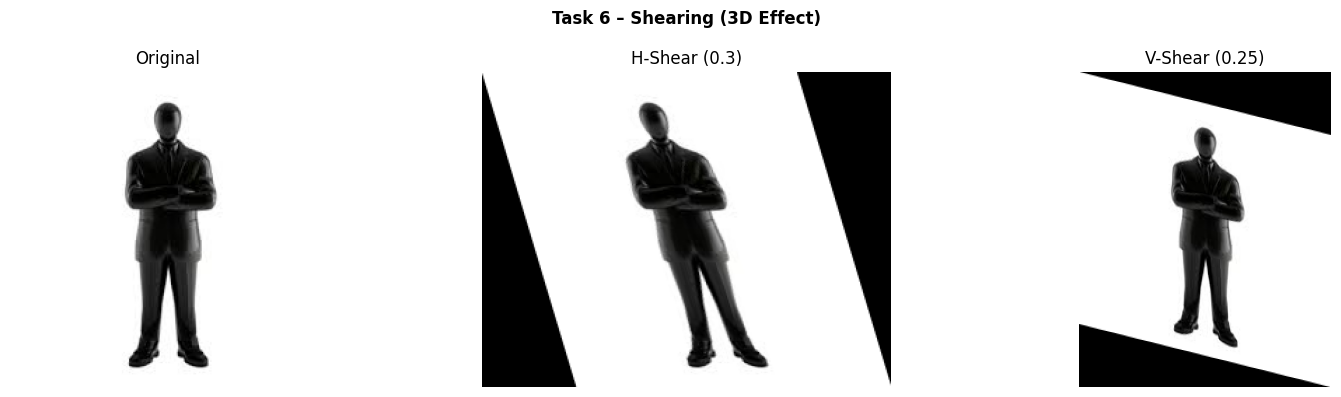

In [7]:
shear_x, shear_y = 0.3, 0.25
M_x = np.array([[1, shear_x, 0],[0, 1, 0]], dtype=np.float32)
M_y = np.array([[1, 0, 0],[shear_y, 1, 0]], dtype=np.float32)

sheared_x = cv2.warpAffine(image, M_x, (int(w + abs(shear_x)*h), h))
sheared_y = cv2.warpAffine(image, M_y, (w, int(h + abs(shear_y)*w)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, img, t in zip(axes, [image, sheared_x, sheared_y],
                      ["Original", f"H-Shear ({shear_x})", f"V-Shear ({shear_y})"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis("off")
plt.suptitle("Task 6 – Shearing (3D Effect)", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Task 7: Image Warping for Panorama Stitching
**Scenario:** Align two overlapping images to create a panorama.

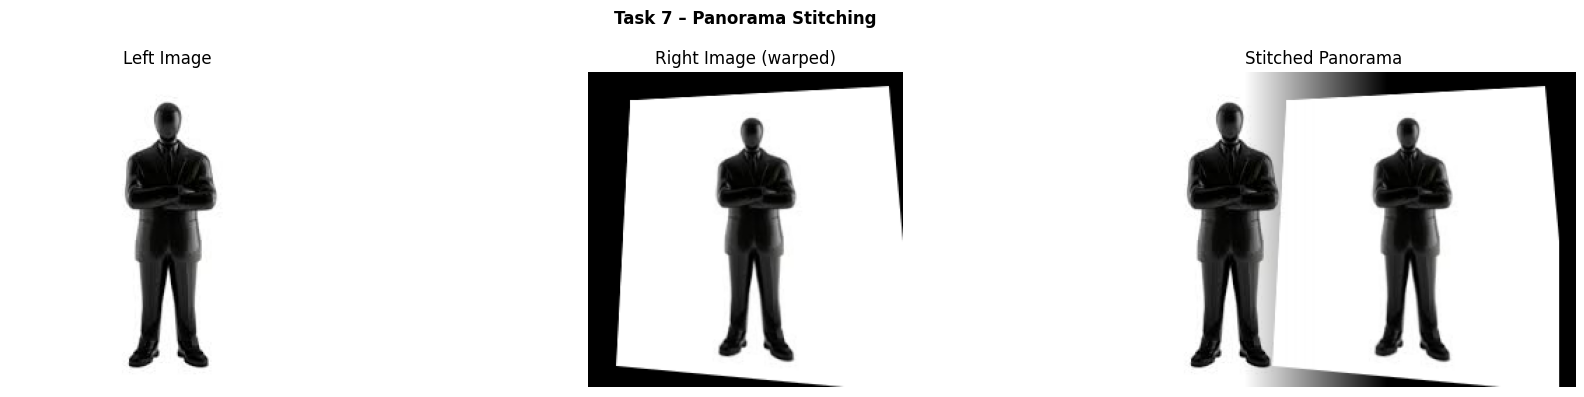

In [8]:
src_pts = np.float32([[0,0],[w,0],[0,h],[w,h]])
dst_pts = np.float32([[30,20],[w-10,10],[20,h-15],[w+10,h+5]])
img2 = cv2.warpPerspective(image, cv2.getPerspectiveTransform(src_pts, dst_pts), (w, h))

pano_w = int(w * 1.6)
panorama = np.zeros((h, pano_w, 3), dtype=np.uint8)
panorama[:, :w] = image
offset_x = int(w * 0.55)
img2_sh = cv2.warpAffine(img2, np.float32([[1,0,offset_x],[0,1,0]]), (pano_w, h))
for x in range(offset_x, min(w, pano_w)):
    alpha = (x - offset_x) / max(w - offset_x, 1)
    panorama[:, x] = ((1-alpha)*panorama[:,x].astype(float) + alpha*img2_sh[:,x].astype(float)).astype(np.uint8)
panorama[:, w:] = img2_sh[:, w:]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, img, t in zip(axes, [image, img2, panorama],
                      ["Left Image", "Right Image (warped)", "Stitched Panorama"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis("off")
plt.suptitle("Task 7 – Panorama Stitching", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Task 8: Apply Multiple Transformations Sequentially
**Scenario:** Simulate a complex photo filter. Order: Scale → Rotate → Translate → Shear.

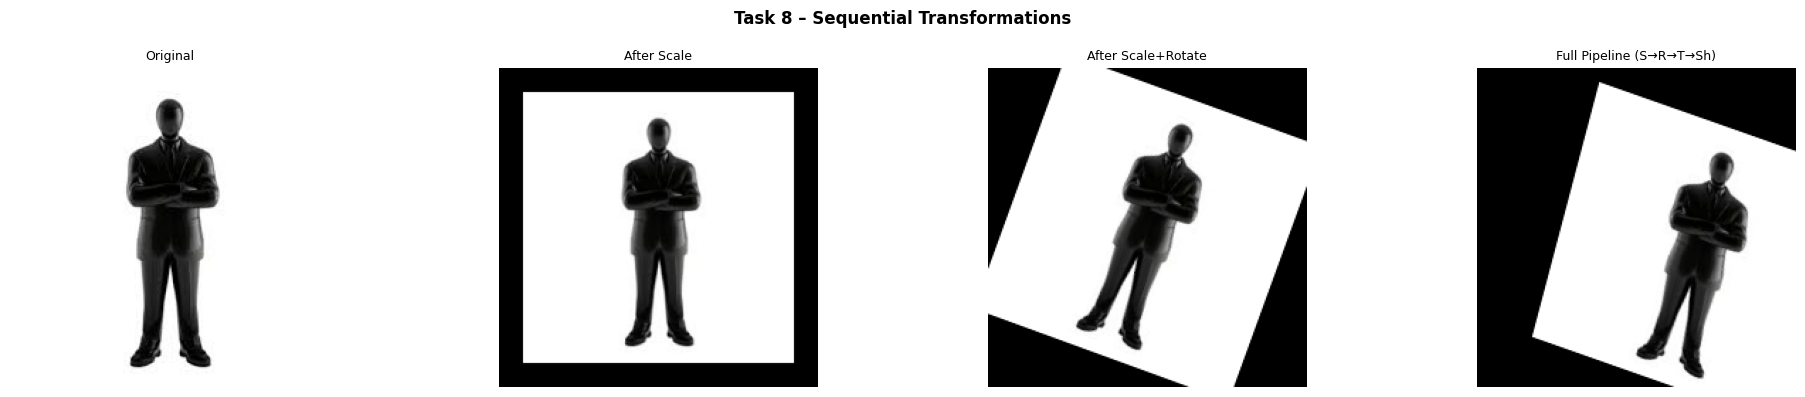

In [9]:
cx, cy = w//2, h//2
sx, sy = 0.85, 0.85
S  = np.array([[sx,0,cx*(1-sx)],[0,sy,cy*(1-sy)],[0,0,1]], dtype=np.float32)
a  = np.radians(20); ca, sa = np.cos(a), np.sin(a)
R  = np.array([[ca,-sa,cx*(1-ca)+cy*sa],[sa,ca,cy*(1-ca)-cx*sa],[0,0,1]], dtype=np.float32)
T  = np.array([[1,0,30],[0,1,20],[0,0,1]], dtype=np.float32)
Sh = np.array([[1,0.1,0],[0,1,0],[0,0,1]], dtype=np.float32)
M  = Sh @ T @ R @ S

imgs = [image,
        cv2.warpPerspective(image, S, (w,h)),
        cv2.warpPerspective(image, R@S, (w,h)),
        cv2.warpPerspective(image, M, (w,h))]
titles = ["Original","After Scale","After Scale+Rotate","Full Pipeline (S→R→T→Sh)"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, img, t in zip(axes, imgs, titles):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t, fontsize=9); ax.axis("off")
plt.suptitle("Task 8 – Sequential Transformations", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Task 9: Image Cropping and Rescaling
**Scenario:** Crop a region of interest and resize it to a fixed dimension for an ID card.

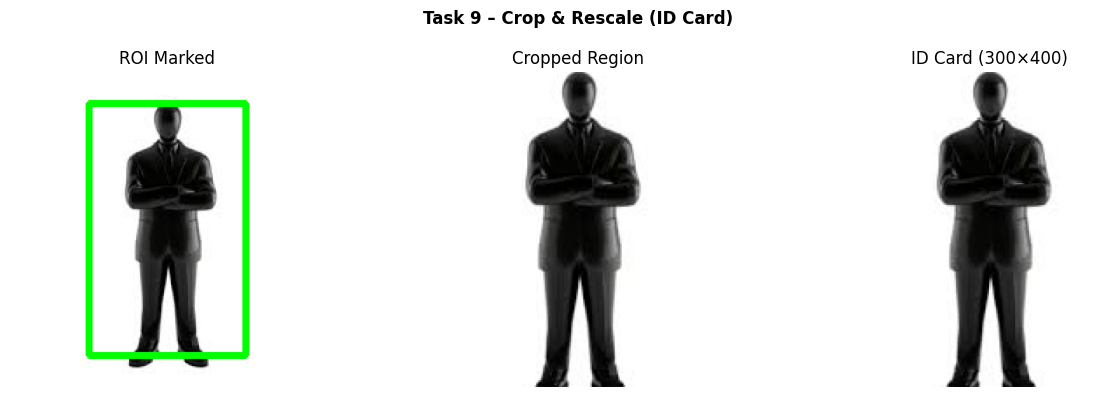

In [10]:
roi_x, roi_y = int(w*0.25), int(h*0.10)
roi_w, roi_h = int(w*0.50), int(h*0.80)
cropped = image[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]

TARGET_W, TARGET_H = 300, 400
scale  = min(TARGET_W/roi_w, TARGET_H/roi_h)
new_w, new_h = int(roi_w*scale), int(roi_h*scale)
resized = cv2.resize(cropped, (new_w, new_h), interpolation=cv2.INTER_AREA)
canvas = np.full((TARGET_H, TARGET_W, 3), 255, dtype=np.uint8)
x_off, y_off = (TARGET_W-new_w)//2, (TARGET_H-new_h)//2
canvas[y_off:y_off+new_h, x_off:x_off+new_w] = resized

vis = image.copy()
cv2.rectangle(vis, (roi_x,roi_y), (roi_x+roi_w,roi_y+roi_h), (0,255,0), 3)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, img, t in zip(axes, [vis, cropped, canvas],
                      ["ROI Marked", "Cropped Region", f"ID Card ({TARGET_W}×{TARGET_H})"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis("off")
plt.suptitle("Task 9 – Crop & Rescale (ID Card)", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Task 10: Extract and Rectify a Region from a Document Image
**Scenario:** Extract a table from a scanned document and transform it to a standard rectangular form.

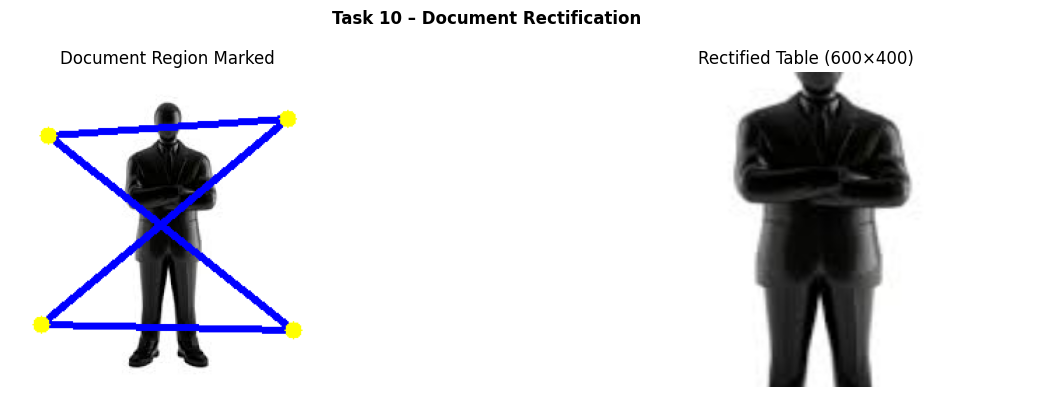

In [11]:
src_pts = np.float32([[w*0.12,h*0.20],[w*0.88,h*0.15],[w*0.10,h*0.80],[w*0.90,h*0.82]])
dst_pts = np.float32([[0,0],[600,0],[0,400],[600,400]])

M = cv2.getPerspectiveTransform(src_pts, dst_pts)
rectified = cv2.warpPerspective(image, M, (600, 400))

vis = image.copy()
cv2.polylines(vis, [src_pts.astype(np.int32)], True, (255,0,0), 3)
for pt in src_pts.astype(np.int32):
    cv2.circle(vis, tuple(pt), max(6,w//60), (0,255,255), -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, img, t in zip(axes, [vis, rectified],
                      ["Document Region Marked", "Rectified Table (600×400)"]):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis("off")
plt.suptitle("Task 10 – Document Rectification", fontweight="bold"); plt.tight_layout(); plt.show()